In [ ]:
from modules.utils import plt_utils, log_utils, samp_utils
from modules import types, configs, environments

In [ ]:
DATASET_TYPE: types.DatasetTypes = "test" # "BGL" | "Liberty" | "Thunderbird"
SAMPLING_TYPE: types.SamplingTypes = "our" # "our" | "logllm"
SLIDING_WIN_TYPE: types.SlidingWindowTypes = "count" # "count" | "time"

Building semantic logs: 100%|██████████| 5000/5000 [00:01<00:00, 3478.74it/s]


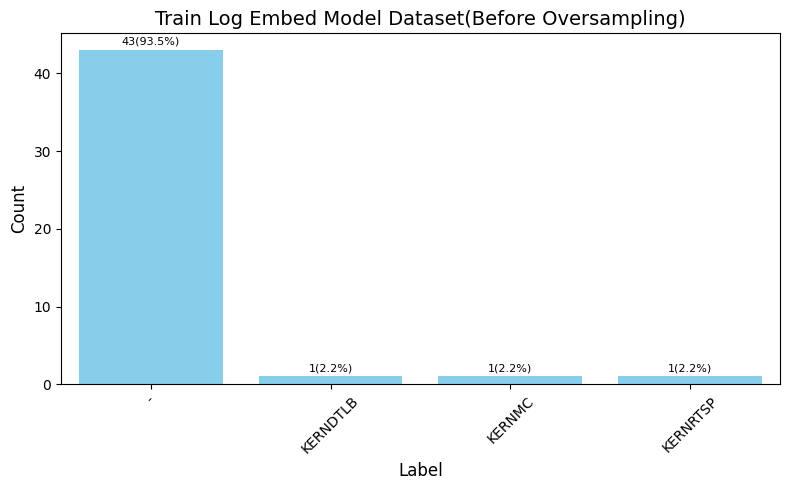

最大類別數量 43 筆
已過採樣類別 'KERNDTLB' : 新增 14 筆
已過採樣類別 'KERNMC' : 新增 14 筆
已過採樣類別 'KERNRTSP' : 新增 14 筆


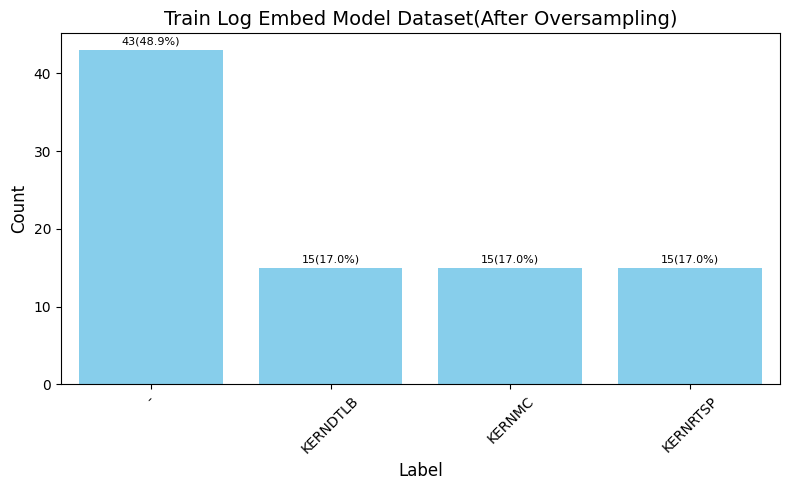

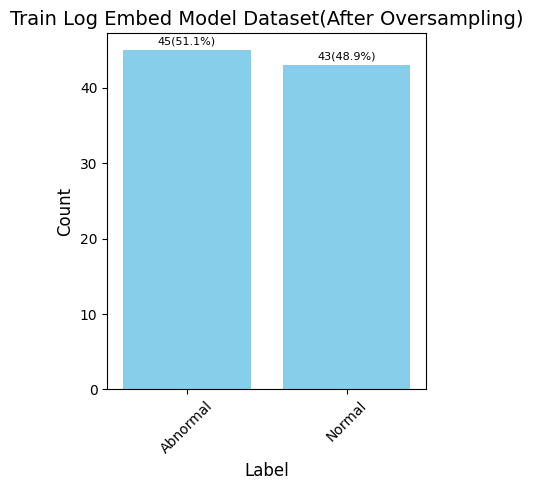

In [3]:
work_config = configs.WORK_CONFIG_MAP[DATASET_TYPE]
ldfh = log_utils.LogDataFrameHelper(work_config.dataset_config.path)
# Build structured logs
struct_logs_df = ldfh.build_struct_logs(
    log_path=work_config.dataset_config.path,
    log_format=work_config.dataset_config.fromat,
    start_line=work_config.dataset_config.start_line,
    end_line=work_config.dataset_config.end_line,
)
# Build semantic logs
logs_df = ldfh.build_semantic_logs(
    struct_logs_df=struct_logs_df,
    feature_columns=work_config.dataset_config.feat_columns,
    log_regex_replase_fn=log_utils.log_regex_replase,
)
# Split training and testing logs
sampling_fn = samp_utils.train_test_sampling if SAMPLING_TYPE == "our" else samp_utils.logllm_train_test_sampling
train_logs_df, test_logs_df = sampling_fn(logs_df, environments.TRAIN_RATIO)
# Build unique logs
train_unique_logs_df = train_logs_df.drop_duplicates(subset=["log", "label"], inplace=False)
train_unique_logs, train_unique_logs_labels = train_unique_logs_df["log"].tolist(), train_unique_logs_df["label"].tolist()
plt_utils.draw_label_distribution(train_unique_logs_labels, title="Train Log Embed Model Dataset(Before Oversampling)")

# Oversamping
oversamp_beta = 1 / (len(set(train_unique_logs_labels)) - 1)
train_logs_oversmap, train_labels_oversmap = samp_utils.minority_oversampling(
    x=train_unique_logs, y=train_unique_logs_labels, beta=oversamp_beta,
)
plt_utils.draw_label_distribution(train_labels_oversmap, title="Train Log Embed Model Dataset(After Oversampling)")

# Binary labels
train_binary_labels = ["Normal" if x == "-" else "Abnormal" for x in train_labels_oversmap]
plt_utils.draw_label_distribution(train_binary_labels, title="Train Log Embed Model Dataset(After Oversampling)")